In [13]:

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [14]:
load_dotenv()

True

In [15]:
class SubState(TypedDict):
    input_text: str 
    translated_text: str 

In [16]:
subgraph_llm = ChatGroq(model="llama-3.1-8b-instant")

In [17]:
def translate_text(state: SubState):
    prompt = f"""
    Translate the following text to Hindi.
    Keep it natural and clear. Do not add extra content.
    
    Text: 
    {state["input_text"]}
    """.strip()
    translate_text = subgraph_llm.invoke(prompt).content 

    return {'translated_text': translate_text}

In [18]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [19]:
class ParentState(TypedDict):
     question: str 
     answer_eng: str 
     answer_hin: str 

In [20]:
parent_llm = ChatGroq(model="llama-3.1-8b-instant")

In [21]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are a helpful assistant.Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [22]:
def translate_answer(state: ParentState):

    result = subgraph.invoke({'input_text': state['answer_eng']})
    
    return {'answer_hin': result['translated']}

In [23]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

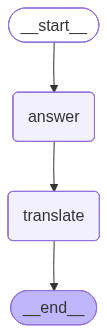

In [24]:
graph = parent_builder.compile()
graph

In [25]:
graph.invoke({'question': 'What is quantum physics'})

KeyError: 'translated'